In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mfdfa
import mfrenyi
import tda
import utils as ut
import time
import pandas as pd


from datasets import load_dataset

path_data = '/Users/jardigarcia/Documents/DATASETS/ART/wikiart_dataset'  # MacBook
ds = load_dataset(path_data)['train']

val_artist = ds.features['artist'].names
val_genre= ds.features['genre'].names
val_style = ds.features['style'].names

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/66 [00:00<?, ?it/s]

In [76]:
"""
MF-DFA 2D: Análisis de Fluctuaciones Detendenciadas Multifractal Bidimensional.

Este módulo implementa el método MF-DFA adaptado para imágenes 2D, incluyendo:
- Construcción del perfil integrado 2D
- Partición en ventanas desde las 4 esquinas
- Ajuste de tendencia polinomial local de segundo orden
- Cálculo de la función de fluctuación generalizada
- Obtención del espectro multifractal f(α) mediante transformada de Legendre
- Extracción de 14 características del espectro

Referencias principales:
    - Kantelhardt et al. (2002). Multifractal detrended fluctuation analysis.
    - Gu & Zhou (2006). Detrended fluctuation analysis for fractals and 
      multifractals in higher dimensions.
    - Ihlen (2012). Introduction to Multifractal Detrended Fluctuation 
      Analysis in Matlab.
"""

import numpy as np
from numba import njit, prange
import utils as ut




# =============================================================================
# Perfil integrado 2D
# =============================================================================

@njit
def profile_2d(img):
    """
    Construye la superficie acumulada (perfil integrado) de una imagen.

    Implementa la suma acumulada doble con media sustraída:
        Y(i,j) = Σ_{k≤i} Σ_{l≤j} [I(k,l) - mean(I)]

    Esta integración transforma la imagen (señal tipo ruido) en una
    superficie tipo caminata aleatoria, condición necesaria para la
    aplicación del DFA (Ihlen, 2012).

    Parameters
    ----------
    img : ndarray (n, m)
        Imagen de entrada en escala de grises.

    Returns
    -------
    Y : ndarray (n, m)
        Perfil integrado 2D.
    """
    img = img - np.mean(img)
    n, m = img.shape
    Y = np.zeros((n, m))

    for i in range(n):
        for j in range(m):
            Y[i, j] = img[i, j]
            if i > 0:
                Y[i, j] += Y[i - 1, j]
            if j > 0:
                Y[i, j] += Y[i, j - 1]
            if i > 0 and j > 0:
                Y[i, j] -= Y[i - 1, j - 1]  # Corrección por doble conteo
    return Y


# =============================================================================
# Partición en ventanas desde las 4 esquinas
# =============================================================================

@njit
def idxy_4(img_shape, s):
    """
    Genera índices de ventanas s×s cubriendo la imagen desde las 4 esquinas.

    Cuando las dimensiones de la imagen no son múltiplo exacto de s,
    las ventanas se inician desde las 4 esquinas para cubrir los
    residuos. Esto sigue el procedimiento estándar de MF-DFA que
    evita perder información en los bordes.

    Parameters
    ----------
    img_shape : tuple (nx, ny)
        Dimensiones de la imagen.
    s : int
        Tamaño de la ventana en píxeles.

    Returns
    -------
    idxy : ndarray (n, 2)
        Coordenadas (i0, j0) de la esquina superior izquierda
        de cada ventana, en orden fila-mayor.
    """
    nx, ny = img_shape
    rx = int((nx % s) != 0)  # 1 si hay residuo en filas
    ry = int((ny % s) != 0)  # 1 si hay residuo en columnas

    # Número total de ventanas considerando las 4 orientaciones
    n = (nx // s) * (ny // s) * (1 + rx + ry + (rx * ry))
    idxy = np.zeros((n, 2), dtype=np.int32)
    idx = 0

    # Esquina superior izquierda → (arriba-abajo, izquierda-derecha)
    for i in range(0, nx - (s * rx), s):
        for j in range(0, ny - (s * ry), s):
            idxy[idx, 0] = i
            idxy[idx, 1] = j
            idx += 1

    # Esquina superior derecha → (arriba-abajo, derecha-izquierda)
    if ry != 0:
        for i in range(0, nx - (s * rx), s):
            for j in range(ny - (s * ry), 0, -s):
                idxy[idx, 0] = i
                idxy[idx, 1] = j
                idx += 1

    # Esquina inferior izquierda → (abajo-arriba, izquierda-derecha)
    if rx != 0:
        for i in range(nx - (s * rx), 0, -s):
            for j in range(0, ny - (s * ry), s):
                idxy[idx, 0] = i
                idxy[idx, 1] = j
                idx += 1

        # Esquina inferior derecha → (abajo-arriba, derecha-izquierda)
        if ry != 0:
            for i in range(nx - (s * rx), 0, -s):
                for j in range(ny - (s * ry), 0, -s):
                    idxy[idx, 0] = i
                    idxy[idx, 1] = j
                    idx += 1

    return idxy


@njit(fastmath=True)
def poly2d_fluctuation_order1(img, i0, j0, s, integration=True):
    """MF-DFA1: detrending lineal (3 coeficientes: i, j, 1)."""
    n = s * s
    Y = np.zeros((s, s), dtype=np.float64)

    if integration:
        mean_val = 0.0
        for di in range(s):
            for dj in range(s):
                mean_val += img[i0 + di, j0 + dj]
        mean_val /= n

        for di in range(s):
            for dj in range(s):
                val = img[i0 + di, j0 + dj] - mean_val
                Y[di, dj] = val
                if di > 0:
                    Y[di, dj] += Y[di - 1, dj]
                if dj > 0:
                    Y[di, dj] += Y[di, dj - 1]
                if di > 0 and dj > 0:
                    Y[di, dj] -= Y[di - 1, dj - 1]
    else:
        for di in range(s):
            for dj in range(s):
                Y[di, dj] = img[i0 + di, j0 + dj]

    # 3 coeficientes: a*i + b*j + c
    A = np.zeros((3, 3), dtype=np.float64)
    b = np.zeros(3, dtype=np.float64)

    for di in range(s):
        for dj in range(s):
            z = Y[di, dj]
            x0 = float(di)
            x1 = float(dj)

            A[0, 0] += x0 * x0
            A[0, 1] += x0 * x1
            A[0, 2] += x0
            A[1, 1] += x1 * x1
            A[1, 2] += x1
            A[2, 2] += 1.0

            b[0] += x0 * z
            b[1] += x1 * z
            b[2] += z

    for i in range(3):
        for j in range(i):
            A[i, j] = A[j, i]

    for k in range(3):
        piv = A[k, k]
        if piv == 0.0:
            return 0.0
        inv = 1.0 / piv
        for j in range(k, 3):
            A[k, j] *= inv
        b[k] *= inv
        for i in range(3):
            if i != k:
                f = A[i, k]
                for j in range(k, 3):
                    A[i, j] -= f * A[k, j]
                b[i] -= f * b[k]

    res = 0.0
    for di in range(s):
        for dj in range(s):
            z_hat = b[0] * di + b[1] * dj + b[2]
            d = Y[di, dj] - z_hat
            res += d * d

    return np.sqrt(res / n)


@njit(fastmath=True)
def poly2d_fluctuation_order2(img, i0, j0, s, integration=True):
    """
    Calcula la fluctuación local en una ventana s×s con detrending
    polinomial de segundo orden e integración local opcional.

    Procedimiento:
    1. Extrae la ventana de la imagen original.
    2. Sustrae la media local de la ventana.
    3. Si integration=True, calcula la suma acumulada 2D LOCAL
       (perfil integrado solo dentro de la ventana).
    4. Ajusta superficie polinomial de segundo orden.
    5. Calcula RMSE de los residuos.

    Parameters
    ----------
    img : ndarray (n, m)
        Imagen original (NO el perfil integrado global).
    i0, j0 : int
        Coordenadas de la esquina superior izquierda de la ventana.
    s : int
        Tamaño de la ventana.
    integration : bool
        Si True, aplica suma acumulada 2D local antes del detrending.

    Returns
    -------
    float
        Fluctuación local (RMSE de los residuos).
    """
    n = s * s

    # --- Paso 1: Integración local (suma acumulada dentro de la ventana) ---
    Y = np.zeros((s, s), dtype=np.float64)

    if integration:
        # Sustraer media local
        mean_val = 0.0
        for di in range(s):
            for dj in range(s):
                mean_val += img[i0 + di, j0 + dj]
        mean_val /= n

        # Suma acumulada 2D local
        for di in range(s):
            for dj in range(s):
                val = img[i0 + di, j0 + dj] - mean_val
                Y[di, dj] = val
                if di > 0:
                    Y[di, dj] += Y[di - 1, dj]
                if dj > 0:
                    Y[di, dj] += Y[di, dj - 1]
                if di > 0 and dj > 0:
                    Y[di, dj] -= Y[di - 1, dj - 1]
    else:
        # Sin integración: usar valores directos
        for di in range(s):
            for dj in range(s):
                Y[di, dj] = img[i0 + di, j0 + dj]

    # --- Paso 2: Detrending polinomial de segundo orden ---
    A = np.zeros((6, 6), dtype=np.float64)
    b = np.zeros(6, dtype=np.float64)

    for di in range(s):
        for dj in range(s):
            z = Y[di, dj]

            x0 = di * di
            x1 = dj * dj
            x2 = di * dj
            x3 = di
            x4 = dj

            A[0, 0] += x0 * x0
            A[0, 1] += x0 * x1
            A[0, 2] += x0 * x2
            A[0, 3] += x0 * x3
            A[0, 4] += x0 * x4
            A[0, 5] += x0

            A[1, 1] += x1 * x1
            A[1, 2] += x1 * x2
            A[1, 3] += x1 * x3
            A[1, 4] += x1 * x4
            A[1, 5] += x1

            A[2, 2] += x2 * x2
            A[2, 3] += x2 * x3
            A[2, 4] += x2 * x4
            A[2, 5] += x2

            A[3, 3] += x3 * x3
            A[3, 4] += x3 * x4
            A[3, 5] += x3

            A[4, 4] += x4 * x4
            A[4, 5] += x4

            A[5, 5] += 1.0

            b[0] += x0 * z
            b[1] += x1 * z
            b[2] += x2 * z
            b[3] += x3 * z
            b[4] += x4 * z
            b[5] += z

    for i in range(6):
        for j in range(i):
            A[i, j] = A[j, i]

    for k in range(6):
        piv = A[k, k]
        if piv == 0.0:
            return 0.0
        inv = 1.0 / piv
        for j in range(k, 6):
            A[k, j] *= inv
        b[k] *= inv

        for i in range(6):
            if i != k:
                f = A[i, k]
                for j in range(k, 6):
                    A[i, j] -= f * A[k, j]
                b[i] -= f * b[k]

    # --- Paso 3: Residuos y RMSE ---
    res = 0.0
    for di in range(s):
        for dj in range(s):
            z_hat = (b[0] * di * di + b[1] * dj * dj + b[2] * di * dj
                     + b[3] * di + b[4] * dj + b[5])
            d = Y[di, dj] - z_hat
            res += d * d

    return np.sqrt(res / n)


@njit(fastmath=True)
def poly2d_fluctuation_order3(img, i0, j0, s, integration=True):
    """MF-DFA3: detrending cúbico (10 coeficientes)."""
    n = s * s
    Y = np.zeros((s, s), dtype=np.float64)

    if integration:
        mean_val = 0.0
        for di in range(s):
            for dj in range(s):
                mean_val += img[i0 + di, j0 + dj]
        mean_val /= n

        for di in range(s):
            for dj in range(s):
                val = img[i0 + di, j0 + dj] - mean_val
                Y[di, dj] = val
                if di > 0:
                    Y[di, dj] += Y[di - 1, dj]
                if dj > 0:
                    Y[di, dj] += Y[di, dj - 1]
                if di > 0 and dj > 0:
                    Y[di, dj] -= Y[di - 1, dj - 1]
    else:
        for di in range(s):
            for dj in range(s):
                Y[di, dj] = img[i0 + di, j0 + dj]

    # 10 coeficientes: i³, j³, i²j, ij², i², j², ij, i, j, 1
    NC = 10
    A = np.zeros((NC, NC), dtype=np.float64)
    bv = np.zeros(NC, dtype=np.float64)

    for di in range(s):
        for dj in range(s):
            z = Y[di, dj]
            ii = float(di)
            jj = float(dj)

            # Bases: i³, j³, i²j, ij², i², j², ij, i, j, 1
            x = np.zeros(NC, dtype=np.float64)
            x[0] = ii * ii * ii
            x[1] = jj * jj * jj
            x[2] = ii * ii * jj
            x[3] = ii * jj * jj
            x[4] = ii * ii
            x[5] = jj * jj
            x[6] = ii * jj
            x[7] = ii
            x[8] = jj
            x[9] = 1.0

            for a in range(NC):
                for bb in range(a, NC):
                    A[a, bb] += x[a] * x[bb]
                bv[a] += x[a] * z

    for i in range(NC):
        for j in range(i):
            A[i, j] = A[j, i]

    for k in range(NC):
        piv = A[k, k]
        if piv == 0.0:
            return 0.0
        inv = 1.0 / piv
        for j in range(k, NC):
            A[k, j] *= inv
        bv[k] *= inv
        for i in range(NC):
            if i != k:
                f = A[i, k]
                for j in range(k, NC):
                    A[i, j] -= f * A[k, j]
                bv[i] -= f * bv[k]

    res = 0.0
    for di in range(s):
        for dj in range(s):
            ii = float(di)
            jj = float(dj)
            z_hat = (bv[0] * ii * ii * ii + bv[1] * jj * jj * jj
                     + bv[2] * ii * ii * jj + bv[3] * ii * jj * jj
                     + bv[4] * ii * ii + bv[5] * jj * jj
                     + bv[6] * ii * jj + bv[7] * ii + bv[8] * jj + bv[9])
            d = Y[di, dj] - z_hat
            res += d * d

    return np.sqrt(res / n)


@njit(parallel=True, fastmath=True)
def local_fluctuation(Y, idxy, s, integration = True, degree_trend = 2):
    """
    Calcula las fluctuaciones locales para todas las ventanas en paralelo.

    Parameters
    ----------
    Y : ndarray (n, m)
        Perfil integrado 2D.
    idxy : ndarray (n_ventanas, 2)
        Coordenadas de cada ventana.
    s : int
        Tamaño de la ventana.

    Returns
    -------
    F_uw : ndarray (n_ventanas,)
        Fluctuación local de cada ventana.
    """
    n = idxy.shape[0]
    F_uw = np.zeros(n)

    for k in prange(n):
        i0 = idxy[k, 0]
        j0 = idxy[k, 1]
        if degree_trend == 1:
            F_uw[k] = poly2d_fluctuation_order2(Y, i0, j0, s, integration = integration)
        if degree_trend == 2:
            F_uw[k] = poly2d_fluctuation_order2(Y, i0, j0, s, integration = integration)    
        if degree_trend == 3:
            F_uw[k] = poly2d_fluctuation_order2(Y, i0, j0, s, integration = integration)

    return F_uw


# # =============================================================================
# # Función de fluctuación generalizada Fq(s)
# # =============================================================================

@njit(parallel=True, fastmath=True)
def mf_fluctuation(f_loc, qs):
    """
    Calcula la función de fluctuación generalizada para múltiples q.

    Para q ≠ 0: Fq = (mean(f_loc^q))^(1/q)
    Para q = 0: Fq = exp(mean(log(f_loc)))

    El caso q=0 se trata por separado porque la fórmula general
    presenta una indeterminación 0/0 en ese punto. La solución
    es el límite por L'Hôpital, que resulta en la media geométrica.

    Parameters
    ----------
    f_loc : ndarray (n,)
        Fluctuaciones locales de todas las ventanas (valores > 0).
    qs : ndarray (nq,)
        Valores de los momentos estadísticos.

    Returns
    -------
    Fq : ndarray (nq,)
        Fluctuación generalizada para cada q.
    """
    nq = qs.shape[0]
    n = f_loc.shape[0]
    Fq = np.zeros(nq)

    for iq in prange(nq):
        q = qs[iq]

        if q == 0.0:
            # Media geométrica (límite de Fq cuando q→0)
            acc = 0.0
            for i in range(n):
                acc += np.log(f_loc[i])
            Fq[iq] = np.exp(acc / n)
        else:
            acc = 0.0
            for i in range(n):
                acc += f_loc[i] ** q
            Fq[iq] = (acc / n) ** (1.0 / q)

    return Fq


# =============================================================================
# MF-DFA completo con extracción de características
# =============================================================================

def mf_dfa_features(
    img,
    q_min=-5.0,
    q_max=5.0,
    s_min=6,
    s_max=0.1,
    integration=True,
    degree_trend = 2
):
    """
    Pipeline completo de MF-DFA 2D con extracción de características.

    Procedimiento:
    1. Genera los valores de q (muestreo no uniforme en [q_min, q_max]).
    2. Genera las escalas s (espaciado logarítmico con degree=3).
    3. Construye el perfil integrado 2D (si integration=True).
    4. Para cada escala: particiona en ventanas, calcula fluctuaciones
       locales, obtiene Fq(s) para todos los q.
    5. Estima h(q) mediante regresión log-log de Fq(s) vs s.
    6. Calcula τ(q) = q·h(q) - 2.
    7. Obtiene f(α) mediante transformada de Legendre.
    8. Extrae 14 características del espectro.

    Parameters
    ----------
    img : ndarray (n, m)
        Imagen en escala de grises.
    q_min : float
        Extremo negativo del rango de momentos.
    q_max : float
        Extremo positivo del rango de momentos.
    s_min : int
        Escala mínima en píxeles.
    s_max : float
        Escala máxima como fracción de la dimensión menor de la imagen
        (ej. 0.1 = 10%, 0.25 = 25%).
    integration : bool
        Si True, construye el perfil integrado antes del análisis.
        Necesario cuando la imagen se comporta como ruido; omitir si
        ya presenta estructura de caminata aleatoria (Ihlen, 2012).

    Returns
    -------
    data : dict
        Datos completos del análisis:
        - 'alpha': exponentes de singularidad α
        - 'f_alpha': espectro multifractal f(α)
        - 'hq': exponente de Hurst generalizado h(q)
        - 'tq': función de masa τ(q)
        - 'qs': valores de q utilizados
        - 's_sizes': escalas utilizadas
    features : dict
        14 características extraídas del espectro:
        - 'a_max': α_max, extremo derecho del espectro
        - 'a_min': α_min, extremo izquierdo del espectro
        - 'dif_a': Δα = α_max - α_min, ancho total del espectro
        - 'a_star': α*, posición del máximo de f(α)
        - 'dif_L': longitud del brazo izquierdo |α* - α_min|
        - 'dif_R': longitud del brazo derecho |α_max - α*|
        - 'asy_i': índice de asimetría (dif_L - dif_R)/(dif_L + dif_R)
        - 'f_max': f(α_max), altura en el extremo derecho
        - 'f_min': f(α_min), altura en el extremo izquierdo
        - 'dif_f': diferencia de alturas max(f) - min(f)
        - 'a': coeficiente cuadrático del ajuste τ(q) ≈ aq² + bq + c
        - 'b': coeficiente lineal del ajuste
        - 'c': término independiente del ajuste
        - 'Hurst': exponente de Hurst (pendiente log F₂(s) vs log s)
    """

    # ---- Valores de q ----
    # qs = np.array(ut.vals_Qs(q_n=q_min, q_p=q_max))
    qs = np.arange(q_min - 0.25,q_max+0.25,0.25)

    # ---- Escalas ----
    img_shape = img.shape
    scales = ut.bineo(s_min, int(min(img.shape) * s_max), degree=2)

    # ---- Perfil integrado ----
    Y = img.copy()
    # if integration:
    #     Y = profile_2d(img)

    nq = qs.shape[0]
    ns = scales.shape[0]

    Fqs = np.zeros((nq, ns), dtype=np.float64)
    F_s = []  # Para el Hurst clásico (q=2)

    # ---- MF-DFA: fluctuaciones por escala ----
    for is_, s in enumerate(scales):
        idxy = idxy_4(img_shape, s)
        idxy = np.ascontiguousarray(idxy, dtype=np.int32)

        f_loc = local_fluctuation(Y, idxy, int(s), integration = integration, degree_trend=degree_trend)

        # Omitir fluctuaciones nulas (ventanas degeneradas)
        f_loc = np.array([f for f in f_loc if f > 0])

        # Fluctuación generalizada para todos los q
        Fqs[:, is_] = mf_fluctuation(f_loc, qs)

        # Fluctuación clásica (q=2) para el exponente de Hurst
        f_s = float(np.sqrt(np.mean(np.power(f_loc, 2))))
        F_s.append(f_s)

    # ---- Exponente de Hurst clásico ----
    vals = np.polyfit(np.log(scales), np.log(F_s), deg=1)

    # ---- h(q): exponente de Hurst generalizado ----
    log_s = np.log(scales)
    hq = np.zeros(nq, dtype=np.float64)
    for iq in range(nq):
        coeffs = np.polyfit(log_s, np.log(Fqs[iq, :]), 1)
        hq[iq] = coeffs[0]

    # ---- τ(q): función de masa ----
    D = 2.0  # Dimensión del espacio (imagen 2D)
    tau_q = qs * hq - D

    # ---- Espectro multifractal f(α) via transformada de Legendre ----
    alpha = np.gradient(tau_q, qs)       # α(q) = dτ/dq
    f_alpha = qs * alpha - tau_q         # f(α) = q·α - τ(q)

    alpha = alpha[1:-1]
    f_alpha = f_alpha[1:-1]

    # ---- Empaquetar datos completos ----
    data = {
        'alpha': np.array(alpha),
        'f_alpha': np.array(f_alpha),
        'hq': np.array(hq),
        'tq': np.array(tau_q),
        'qs': np.array(qs),
        's_sizes': np.array(scales),
        'fluctuations': Fqs,
    }

    # # ---- Extracción de 14 características ----

    # # Extremos y ancho del espectro
    # a_max = data['alpha'][0]          # Extremo derecho (q más negativo)
    # a_min = data['alpha'][-1]         # Extremo izquierdo (q más positivo)
    # dif_a = np.abs(a_max - a_min)     # Ancho total Δα

    # # Posición del máximo
    # a_star = data['alpha'][data['f_alpha'] == np.max(data['f_alpha'])][0]

    # # Asimetría del espectro
    # dif_L = np.abs(a_star - a_min)    # Brazo izquierdo
    # dif_R = np.abs(a_max - a_star)    # Brazo derecho
    # asy_i = (dif_L - dif_R) / (dif_L + dif_R)  # Índice de asimetría

    # # Alturas del espectro
    # f_max = data['f_alpha'][0]        # Altura en α_max
    # f_min = data['f_alpha'][-1]       # Altura en α_min
    # dif_f = np.abs(np.max(data['f_alpha']) - np.min(data['f_alpha']))

    # # Ajuste cuadrático de τ(q): captura la curvatura global
    # a, b, c = np.polyfit(data['qs'], data['tq'], 2)

    # features = {
    #     'a_max': float(a_max),
    #     'a_min': float(a_min),
    #     'dif_a': float(dif_a),
    #     'a_star': float(a_star),
    #     'dif_L': float(dif_L),
    #     'dif_R': float(dif_R),
    #     'asy_i': float(asy_i),
    #     'f_max': float(f_max),
    #     'f_min': float(f_min),
    #     'dif_f': float(dif_f),
    #     'a': float(a),
    #     'b': float(b),
    #     'c': float(c),
    #     'Hurst': float(vals[0])
    # }

    return data#, features

In [70]:
dic_data = {'id':[],'movimiento':[],'artista':[],'genero':[]}


errores = []
q_min = -5
q_max = 5
s_min = 6
s_max = 10

for id,item in enumerate(ds):

    try:
        
        img_norm = ut.normalize_image(np.array(item['image']), max_size=1380, gray=True)

        for n_segment in range(1,5): 
            list_i = ut.segment_image(img_norm, grid_size = n_segment)
        
            for position,img_p in enumerate(list_i):
                print(img_p)
                data_dfa, features_dfa = mfdfa.mf_dfa_features(img=img_p, q_min=q_min, q_max=q_max, s_min=s_min,s_max=s_max, integration=True, degree_trend=2)
                print(f'dfa {position}')
                data_renyi, features_renyi = mfrenyi.mf_renyi_features(img=img_p, q_min=q_min, q_max=q_max, s_min=s_min,s_max=s_max)
                print(f'renyi {position}')

                for f in features_dfa.keys():
                    f_name = 'DFA' + f + '_' + str(n_segment) +'_'+ str(position + 1)
                    if f_name in dic_data.keys():
                        dic_data[f_name].append(features_dfa[f])
                    else:
                        dic_data[f_name] = [features_dfa[f]]

                for measure in ('sum','var','ent'):
                    for f in features_renyi.keys():
                        f_name = measure + f + '_' + str(n_segment) +'_'+ str(position + 1)
                        if f_name in dic_data.keys():
                            dic_data[f_name].append(features_renyi[measure]['f'])
                        else:
                            dic_data[f_name] = [features_renyi[measure][f]]



        dic_data['id'].append(id)
        dic_data['movimiento'].append(val_style[item['style']])
        dic_data['artista'].append(val_style[item['artist']])
        dic_data['genero'].append(val_style[item['genre']])
    
    except Exception as e:
        errores.append((id, str(e)))
        
    if id == 0:
        break


[[144 147 163 ... 148 147 147]
 [145 148 159 ... 141 138 138]
 [146 148 158 ... 139 136 135]
 ...
 [156 151 125 ...  59  43  40]
 [143 139 115 ...  60  44  41]
 [ 98  95  82 ...  62  47  44]]


/Users/jardigarcia/.pyenv/versions/3.13.7/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jardigarcia/.pyenv/versions/3.13.7/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [95]:
data_dfa = mf_dfa_features(img=img_p, q_min=q_min, q_max=q_max, s_min=s_min,s_max=0.1, integration=False, degree_trend=2)

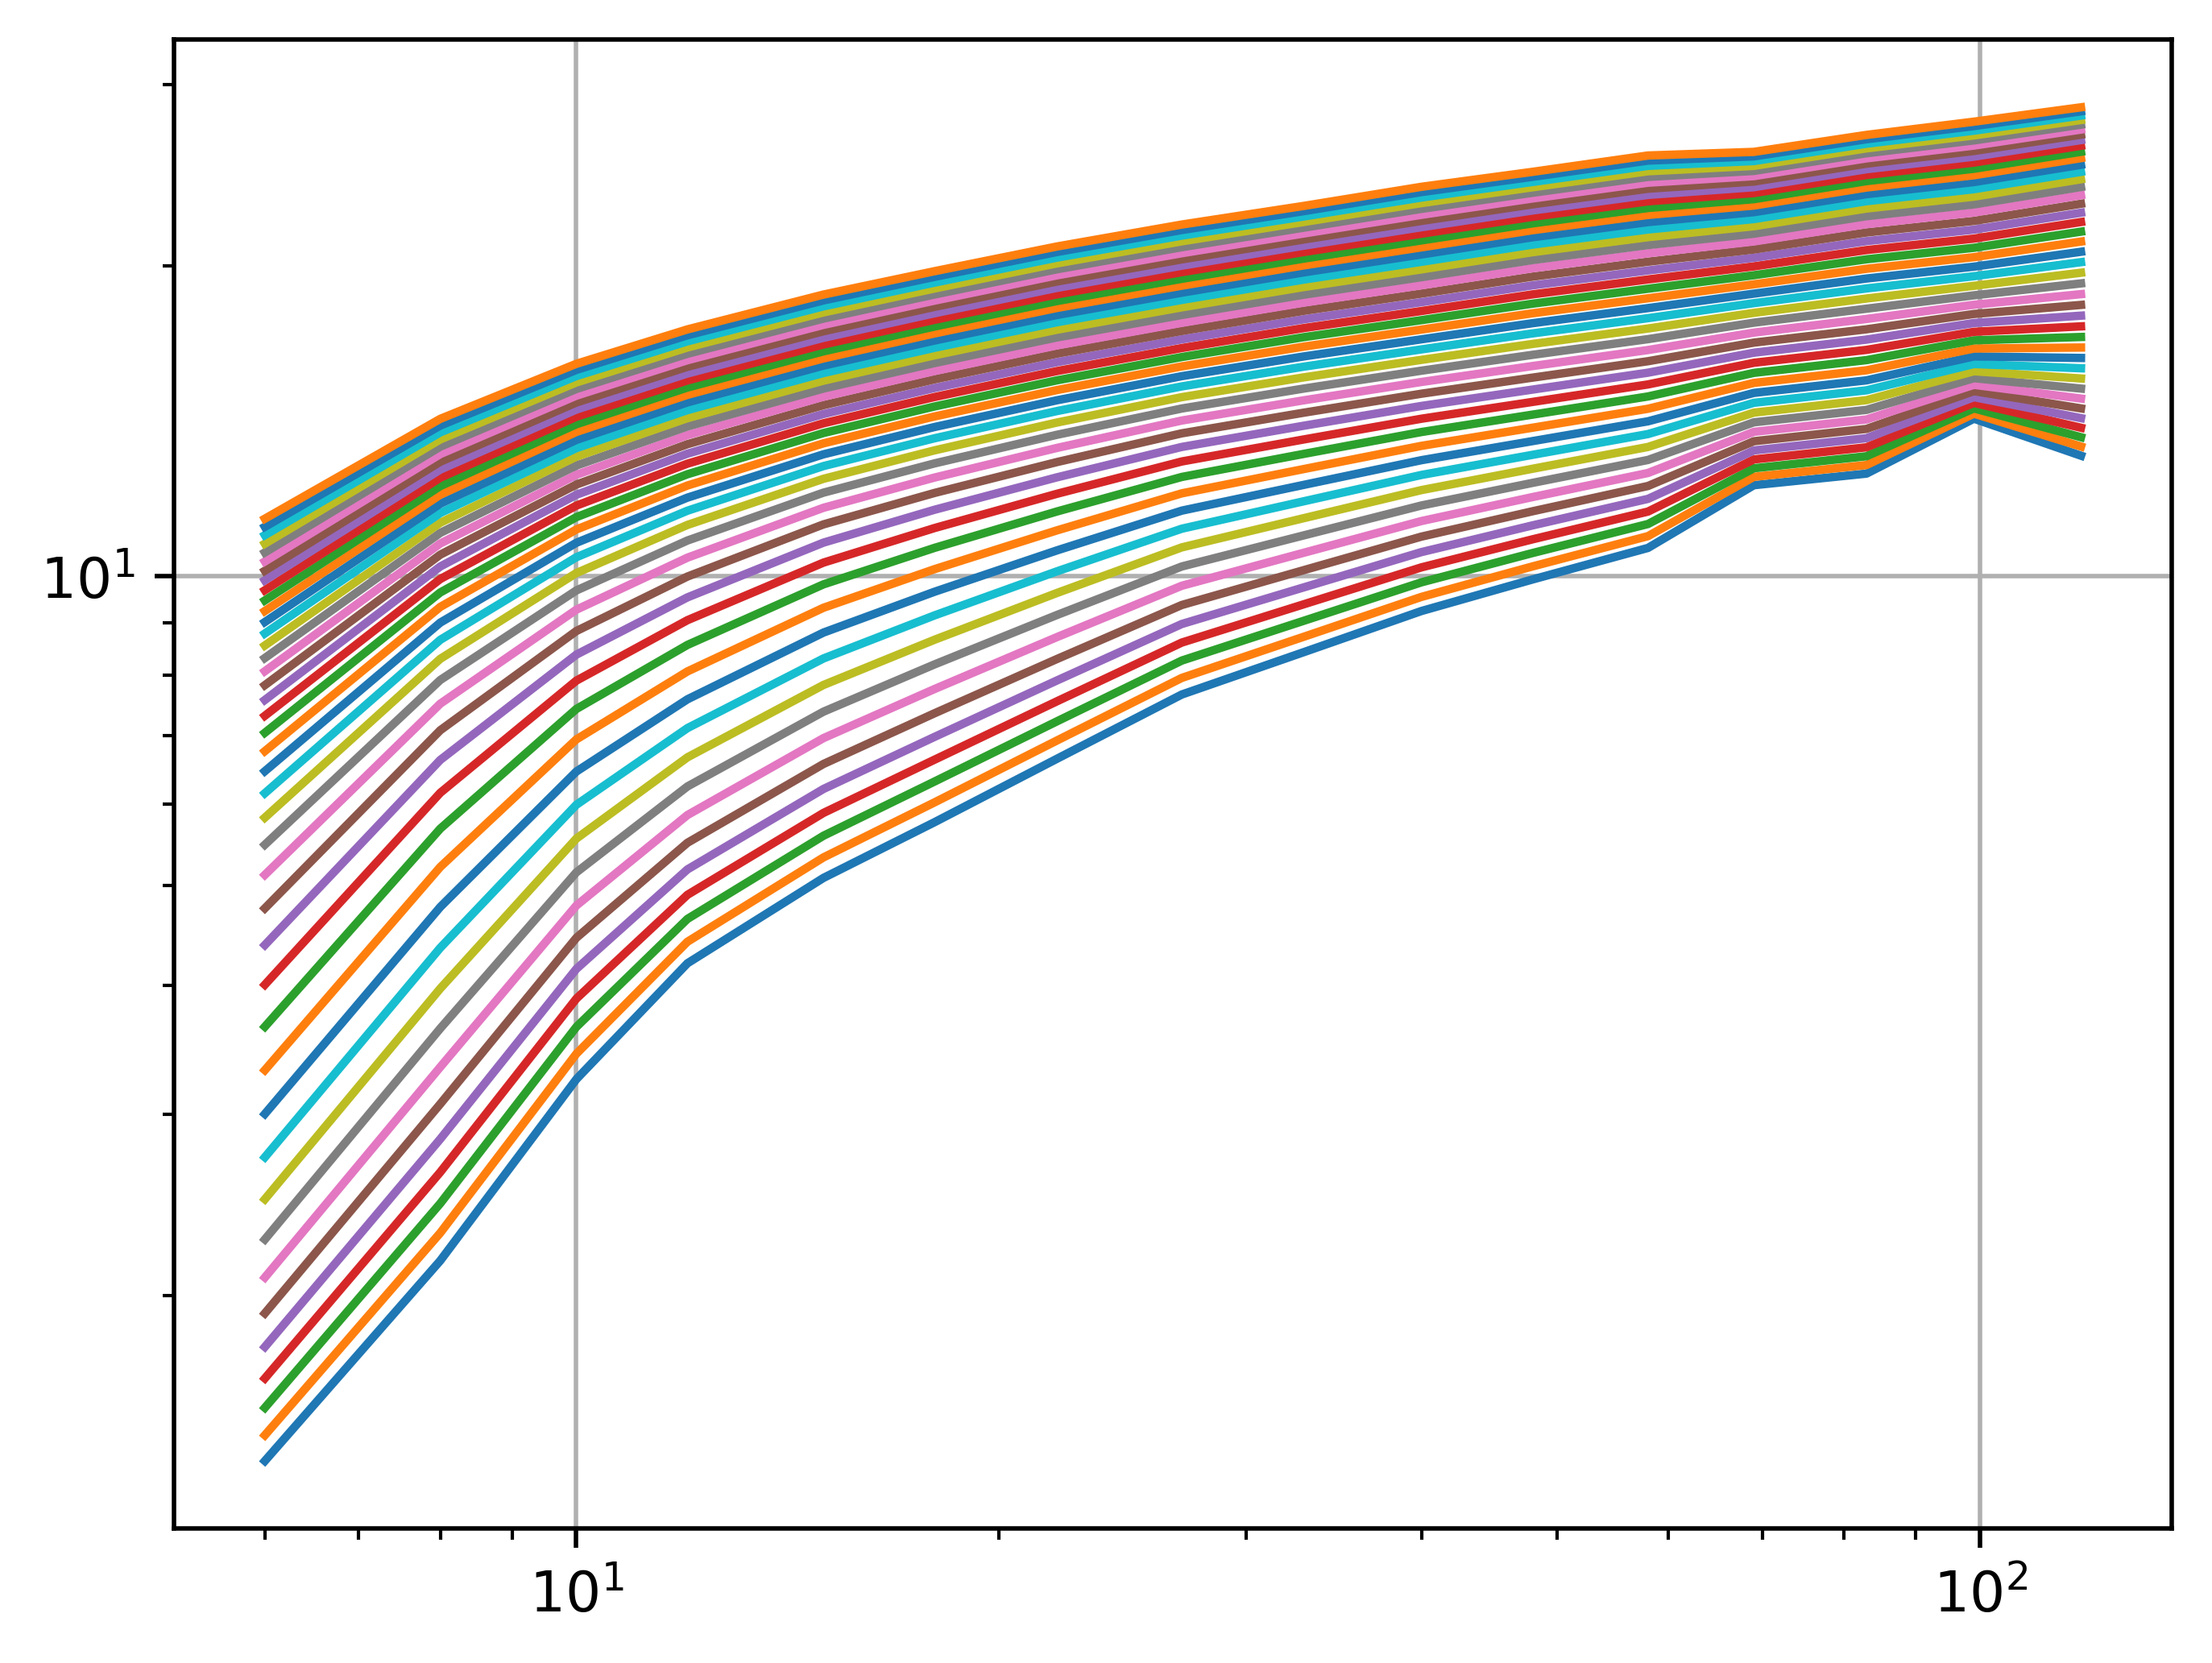

In [96]:
plt.figure(dpi = 500)
for f in data_dfa['fluctuations']:
    plt.plot(data_dfa['s_sizes'],f)

plt.loglog()
plt.grid()

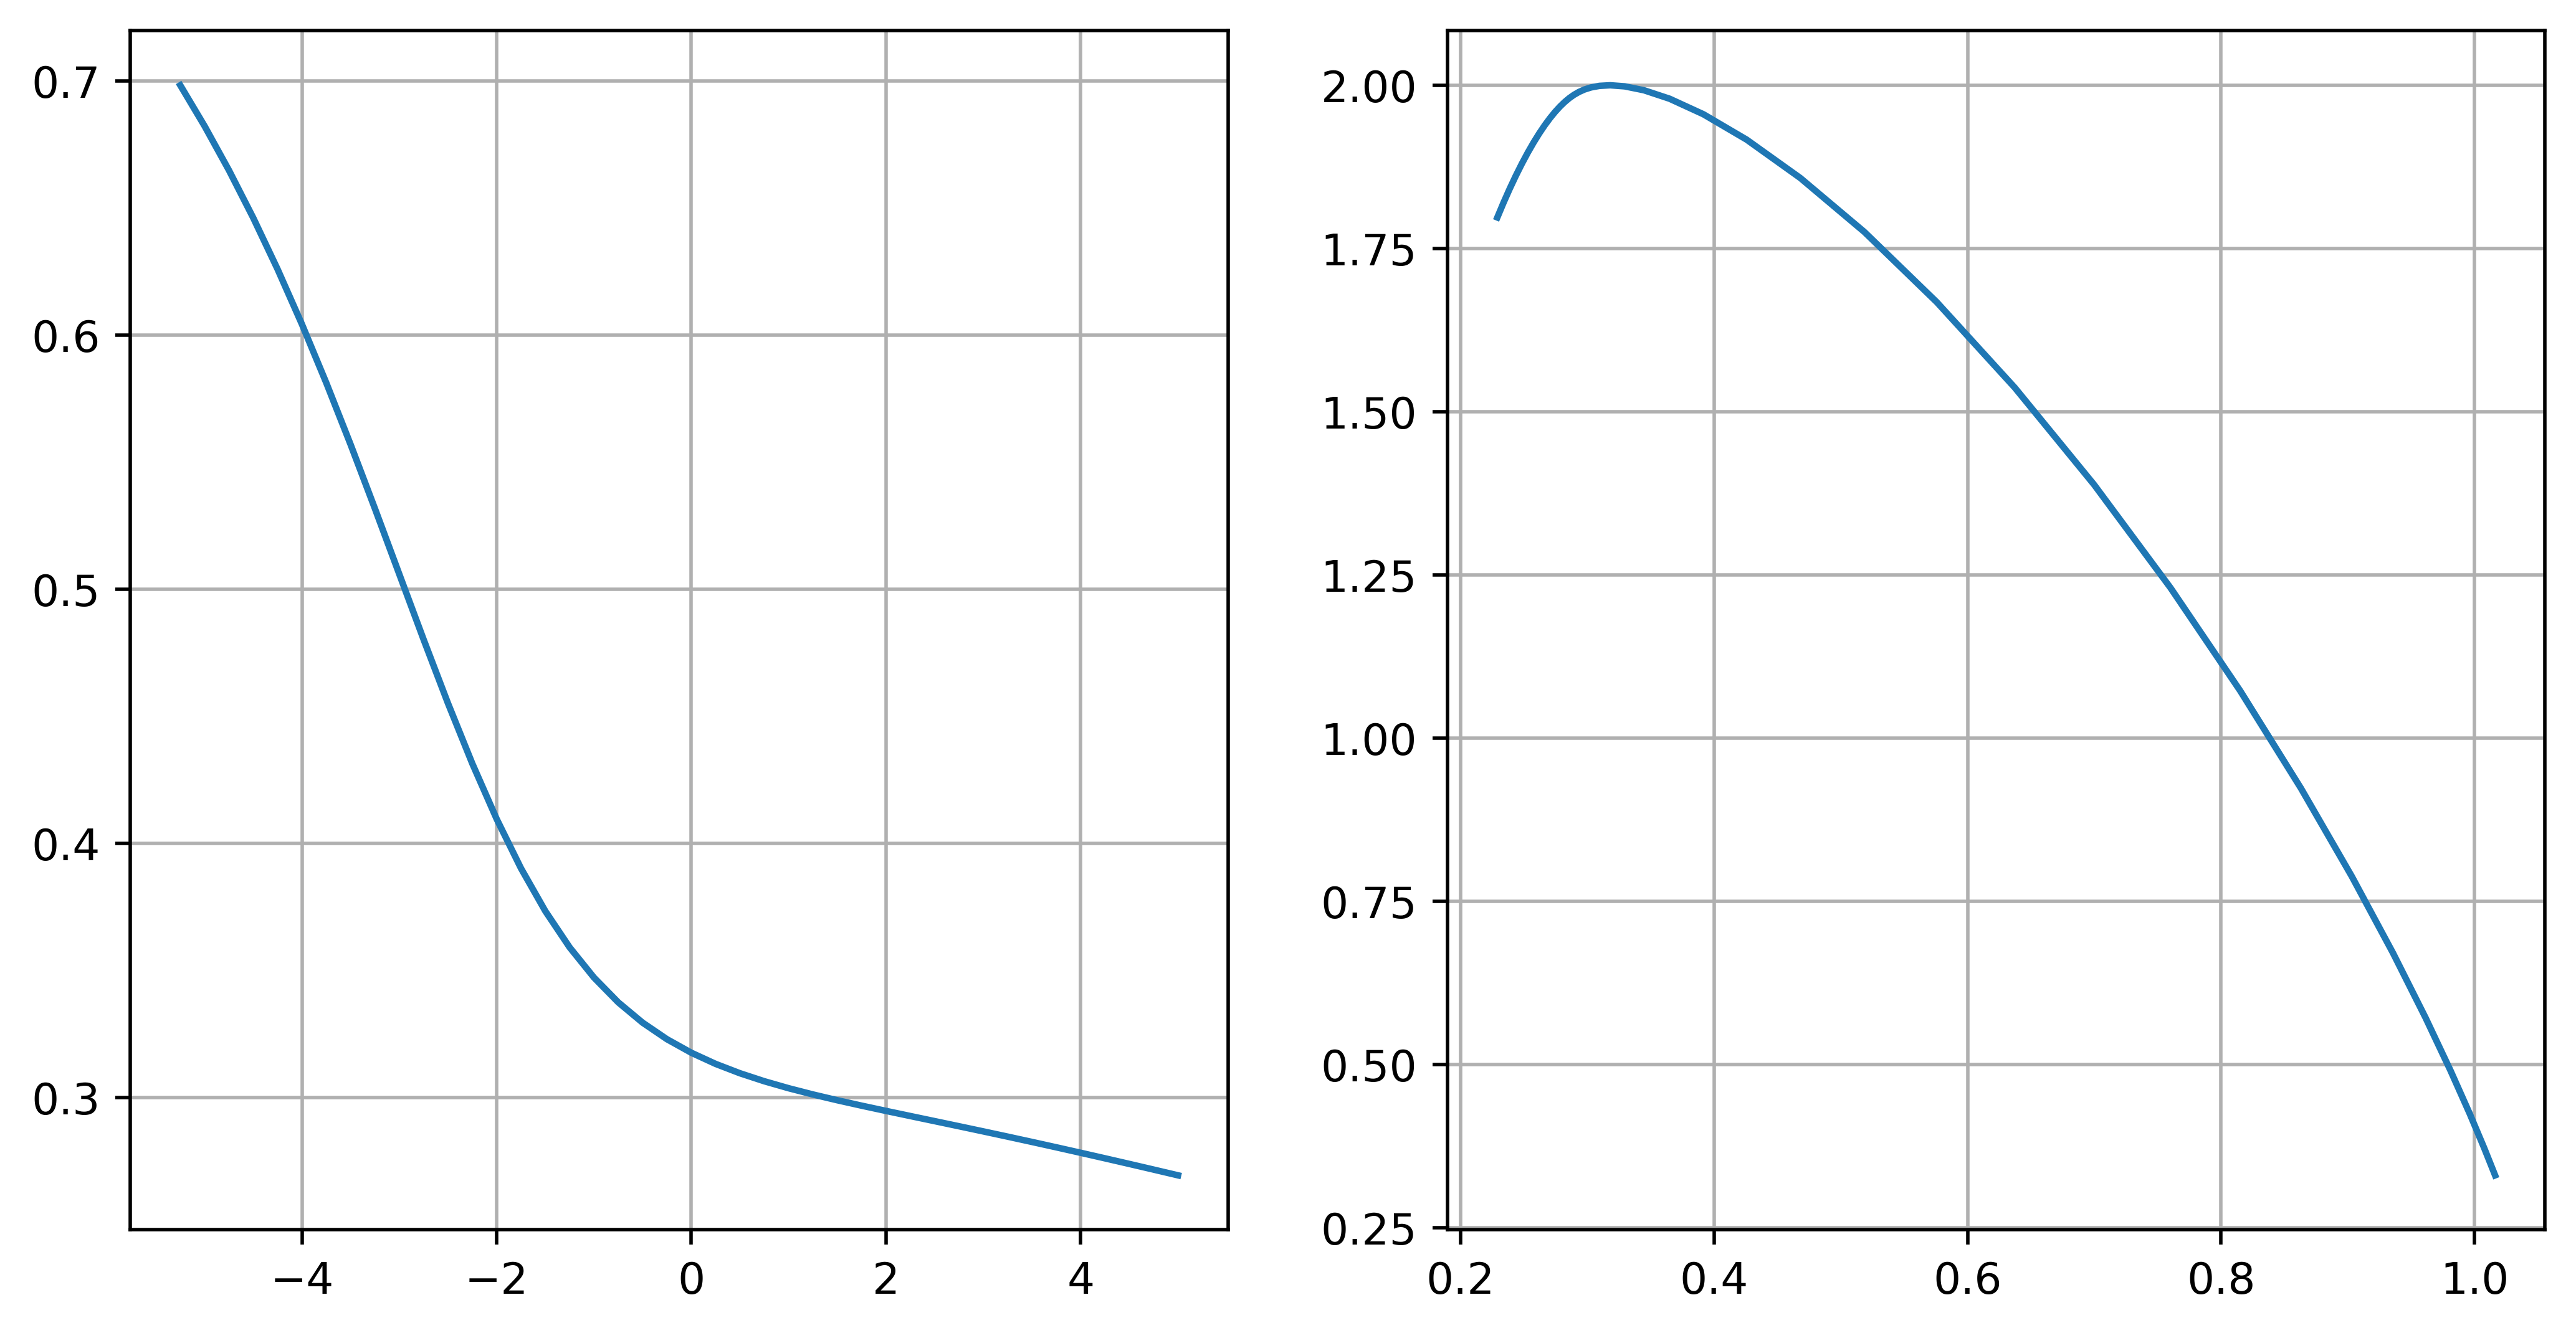

In [97]:
plt.figure(figsize=(10,5), dpi = 500)

plt.subplot(1,2,1)
plt.plot(data_dfa['qs'], data_dfa['hq'])
plt.grid()

plt.subplot(1,2,2)
plt.plot(data_dfa['alpha'], data_dfa['f_alpha'])
plt.grid()


In [67]:
pd.DataFrame(dic_data).set_index('id')

,movimiento,artista,genero
id,,,


In [ ]:
val_artist = ds.features['artist'].names
val_genre= ds.features['genre'].names
val_style = ds.features['style'].names

['Unknown Artist',
 'boris-kustodiev',
 'camille-pissarro',
 'childe-hassam',
 'claude-monet',
 'edgar-degas',
 'eugene-boudin',
 'gustave-dore',
 'ilya-repin',
 'ivan-aivazovsky',
 'ivan-shishkin',
 'john-singer-sargent',
 'marc-chagall',
 'martiros-saryan',
 'nicholas-roerich',
 'pablo-picasso',
 'paul-cezanne',
 'pierre-auguste-renoir',
 'pyotr-konchalovsky',
 'raphael-kirchner',
 'rembrandt',
 'salvador-dali',
 'vincent-van-gogh',
 'hieronymus-bosch',
 'leonardo-da-vinci',
 'albrecht-durer',
 'edouard-cortes',
 'sam-francis',
 'juan-gris',
 'lucas-cranach-the-elder',
 'paul-gauguin',
 'konstantin-makovsky',
 'egon-schiele',
 'thomas-eakins',
 'gustave-moreau',
 'francisco-goya',
 'edvard-munch',
 'henri-matisse',
 'fra-angelico',
 'maxime-maufra',
 'jan-matejko',
 'mstislav-dobuzhinsky',
 'alfred-sisley',
 'mary-cassatt',
 'gustave-loiseau',
 'fernando-botero',
 'zinaida-serebriakova',
 'georges-seurat',
 'isaac-levitan',
 'joaquã\xadn-sorolla',
 'jacek-malczewski',
 'berthe-moriso